# Customer Retention Enhancement - Task 1
## Data Gathering and Exploratory Analysis

**Author:** Manoj, Data Science Graduate  
**Reviewer:** Li, Senior Data Scientist  
**Client:** SmartBank (subsidiary of Lloyds Banking Group)

---

This notebook documents the work I have done for Phase 1 of the Customer Retention Enhancement project. I have gathered the five supplied data sources, aggregated them to one row per customer, run exploratory analysis with appropriate statistical tests, and produced a cleaned dataset that is ready for Phase 2 modelling. The notebook is self-contained: re-running every cell in order reproduces every figure, table and number in the accompanying report.

## 1. Setup

I am using the standard Python data-science stack with SciPy for the statistical tests and scikit-learn for the modelling pipeline pattern shown later. The colour palette follows Lloyds brand guidance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 10})

# Lloyds palette
LLOYDS_GREEN = '#006A4D'
LLOYDS_LIGHT = '#7AB800'
ACCENT_RED = '#D4001A'
LLOYDS_DIV = LinearSegmentedColormap.from_list(
    'lloyds_div', [(0.0, ACCENT_RED), (0.5, '#FFFFFF'), (1.0, LLOYDS_GREEN)])

INPUT_FILE = 'Customer_Churn_Data_Large.xlsx'
REFERENCE_DATE = pd.Timestamp('2024-01-01')  # provisional — see report Limitations 4.1

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"'{INPUT_FILE}' not found in the working directory. "
        "Place the raw workbook beside this notebook before running.")

## 2. Source data

I have loaded all five sheets from the supplied workbook. The cell below also runs the basic quality checks I rely on: row counts, unique-customer coverage per sheet, missingness and duplicates.

In [2]:
all_sheets = pd.read_excel(INPUT_FILE, sheet_name=None)
demo = all_sheets['Customer_Demographics']
trans = all_sheets['Transaction_History']
service = all_sheets['Customer_Service']
online = all_sheets['Online_Activity']
churn = all_sheets['Churn_Status']

summary = []
for name, sheet_df in all_sheets.items():
    summary.append({
        'Sheet': name,
        'Rows': sheet_df.shape[0],
        'Unique customers': sheet_df['CustomerID'].nunique(),
        'Missing values': sheet_df.isnull().sum().sum(),
        'Duplicate rows': sheet_df.duplicated().sum()
    })
pd.DataFrame(summary)

,Sheet,Rows,Unique customers,Missing values,Duplicate rows
0,Customer_Demographics,1000,1000,0,0
1,Transaction_History,5054,1000,0,0
2,Customer_Service,1002,668,0,0
3,Online_Activity,1000,1000,0,0
4,Churn_Status,1000,1000,0,0


The data is clean: no missing values and no duplicate rows across any sheet. Demographics, Transaction_History, Online_Activity and Churn_Status each cover all 1,000 customers. Customer_Service only covers 668. I will treat the 332 customers without service records as having zero interactions — this is informative absence, not missingness.

I note that the data is unusually clean for a banking dataset. The Limitations section of the report addresses this point explicitly.

In [3]:
# Target class balance
churn_rate = churn['ChurnStatus'].mean()
print(f'Class balance: {dict(churn["ChurnStatus"].value_counts())}')
print(f'Churn rate: {churn_rate*100:.2f}%')

Class balance: {0: np.int64(796), 1: np.int64(204)}
Churn rate: 20.40%


204 of 1,000 customers churned. The 79.6 to 20.4 split is moderately imbalanced — enough to disqualify accuracy as a useful metric, but not so extreme that the positive class is unworkable.

## 3. Building the customer-level table

I am collapsing the long-format transaction and service tables to one row per customer, since the model needs a customer-level view. I am preserving the spend mix per customer through five `SpendShare_<Category>` features rather than using the modal category, which would discard information about how the spending was distributed.

**Engineered features I am creating:** 11 from transactions (transaction counts, totals, averages, maxima, minima, recency, plus the five spend shares), 3 from customer service, and 1 from online activity. That makes **15 engineered customer-level features**. Combined with the encoded demographic and channel variables, the final dataset has **26 predictor features**.

In [4]:
# Transaction-level aggregations
trans_agg = trans.groupby('CustomerID').agg(
    TotalTransactions=('TransactionID', 'count'),
    TotalSpent=('AmountSpent', 'sum'),
    AvgSpent=('AmountSpent', 'mean'),
    MaxSpent=('AmountSpent', 'max'),
    MinSpent=('AmountSpent', 'min'),
    LastTransactionDate=('TransactionDate', 'max'),
).reset_index()

# Category spend shares — compositional, sum to 1.0 per customer
spend_by_cat = trans.groupby(['CustomerID', 'ProductCategory'])['AmountSpent'].sum().unstack(fill_value=0)
share = spend_by_cat.div(spend_by_cat.sum(axis=1), axis=0)
share.columns = [f'SpendShare_{c}' for c in share.columns]
share = share.reset_index()

# Service interactions — count, complaints, unresolved
service_agg = service.groupby('CustomerID').agg(
    TotalInteractions=('InteractionID', 'count'),
    ComplaintCount=('InteractionType', lambda x: (x == 'Complaint').sum()),
    UnresolvedCount=('ResolutionStatus', lambda x: (x == 'Unresolved').sum()),
).reset_index()

# Merge everything onto the demographics base
df = (demo
      .merge(trans_agg, on='CustomerID', how='left')
      .merge(share, on='CustomerID', how='left')
      .merge(service_agg, on='CustomerID', how='left')
      .merge(online, on='CustomerID', how='left')
      .merge(churn, on='CustomerID', how='left'))

# Zero-fill service counts for customers without service contact
for col in ['TotalInteractions', 'ComplaintCount', 'UnresolvedCount']:
    df[col] = df[col].fillna(0).astype(int)

# Recency features — the reference date is provisional until the
# churn-measurement date is verified with the project sponsor (see report 4.1)
df['DaysSinceLastLogin'] = (REFERENCE_DATE - df['LastLoginDate']).dt.days
df['DaysSinceLastTransaction'] = (REFERENCE_DATE - df['LastTransactionDate']).dt.days

# Build a robust modal-category reference for EDA only — not used as a model feature
mode_cat = (trans.groupby('CustomerID')['ProductCategory']
            .agg(lambda x: x.mode().sort_values().iloc[0]))
df['_modal_cat'] = df['CustomerID'].map(mode_cat)

print(f'Customer-level table: {df.shape}')
df.head(3)

Customer-level table: (1000, 26)


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalTransactions,TotalSpent,AvgSpent,MaxSpent,MinSpent,LastTransactionDate,SpendShare_Books,SpendShare_Clothing,SpendShare_Electronics,SpendShare_Furniture,SpendShare_Groceries,TotalInteractions,ComplaintCount,UnresolvedCount,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,DaysSinceLastLogin,DaysSinceLastTransaction,_modal_cat
0,1,62,M,Single,Low,1,416.500,416.500,416.500,416.500,2022-03-27,0.000,0.000,1.000,0.000,0.000,1,0,0,2023-10-21,34,Mobile App,0,72,645,Electronics
1,2,65,M,Married,Low,7,"1,547.420",221.060,397.370,54.960,2022-11-19,0.000,0.292,0.513,0.065,0.129,1,0,0,2023-12-05,5,Website,1,27,408,Electronics
2,3,18,M,Single,Low,6,"1,702.980",283.830,419.950,51.070,2022-10-08,0.142,0.030,0.000,0.483,0.345,1,0,0,2023-11-15,3,Website,0,47,450,Furniture


## 4. Statistical testing for categorical features

Before drawing any conclusions about which customer groups churn more, I am running a chi-square test of independence for each categorical variable and computing Wilson 95% confidence intervals for each group's churn rate. Cramér's V quantifies effect size.

In [5]:
def wilson_ci(k, n, conf=0.95):
    """Wilson confidence interval for a binomial proportion. Better than normal approximation at small n."""
    if n == 0:
        return (np.nan, np.nan, np.nan)
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (p, centre - half, centre + half)

test_results = []
for var in ['Gender', 'MaritalStatus', 'IncomeLevel', '_modal_cat', 'ServiceUsage']:
    ct = pd.crosstab(df[var], df['ChurnStatus'])
    chi2, p, dof, _ = stats.chi2_contingency(ct, correction=False)
    n_total = ct.values.sum()
    v = np.sqrt(chi2 / (n_total * (min(ct.shape) - 1)))
    test_results.append({
        'Variable': var.replace('_modal_cat', 'PreferredCategory (modal)'),
        'chi-square': chi2,
        'dof': dof,
        'p-value': p,
        "Cramer's V": v,
        'Significant at 0.05': 'Yes' if p < 0.05 else 'No'
    })

pd.DataFrame(test_results).round({'chi-square': 2, 'p-value': 3, "Cramer's V": 3})

,Variable,chi-square,dof,p-value,Cramer's V,Significant at 0.05
0,Gender,0.330,1,0.566,0.018,No
1,MaritalStatus,1.720,3,0.633,0.041,No
2,IncomeLevel,0.970,2,0.616,0.031,No
3,PreferredCategory (modal),2.750,4,0.601,0.052,No
4,ServiceUsage,2.850,2,0.241,0.053,No


None of the categorical variables is significantly associated with churn. Every Cramér's V is below 0.06, meaning effect sizes are negligible. I will treat any group-level differences in the figures below as descriptive observations only — not as findings for the retention team to act on.

## 5. Statistical testing for numerical features

For each numerical feature, I am computing the point-biserial correlation with churn and a Fisher-z 95% confidence interval. The point-biserial correlation is the right test for a continuous predictor against a binary target.

In [6]:
num_cols = ['Age', 'TotalTransactions', 'TotalSpent', 'AvgSpent', 'MaxSpent',
            'MinSpent', 'TotalInteractions', 'ComplaintCount', 'UnresolvedCount',
            'LoginFrequency', 'DaysSinceLastLogin', 'DaysSinceLastTransaction']

n = len(df)
se = 1 / np.sqrt(n - 3)
pb_rows = []
for col in num_cols:
    r, p = stats.pointbiserialr(df['ChurnStatus'], df[col])
    z = np.arctanh(r)
    pb_rows.append({
        'Feature': col,
        'r': r,
        'CI low': np.tanh(z - 1.96 * se),
        'CI high': np.tanh(z + 1.96 * se),
        'p-value': p,
        'Significant at 0.05': 'Yes' if p < 0.05 else 'No'
    })

pb_df = pd.DataFrame(pb_rows).sort_values('r', key=lambda x: x.abs(), ascending=False)
pb_df.round({'r': 4, 'CI low': 4, 'CI high': 4, 'p-value': 3})

,Feature,r,CI low,CI high,p-value,Significant at 0.05
9,LoginFrequency,-0.082,-0.143,-0.020,0.010,Yes
3,AvgSpent,0.045,-0.017,0.106,0.157,No
4,MaxSpent,0.035,-0.027,0.097,0.271,No
0,Age,0.029,-0.033,0.091,0.353,No
5,MinSpent,0.019,-0.043,0.081,0.537,No
7,ComplaintCount,0.017,-0.045,0.079,0.600,No
10,DaysSinceLastLogin,0.009,-0.053,0.071,0.775,No
1,TotalTransactions,-0.009,-0.071,0.053,0.786,No
8,UnresolvedCount,0.005,-0.057,0.067,0.871,No
6,TotalInteractions,0.005,-0.057,0.067,0.878,No


Only `LoginFrequency` reaches statistical significance, with r = -0.082. The effect is statistically distinguishable from zero but the magnitude is small: less than 1% of churn variation is explained by login frequency alone. The direction is intuitive — churners log in less often — but the size of the effect should temper any expectation of a strong single-feature predictor.

I also flag a temporal concern with `LoginFrequency` and `DaysSinceLastLogin`. Both are measured in 2023, while the transaction window runs through 2022 and the churn label has no associated measurement date. If a customer churned during 2022, low 2023 login activity is a consequence of leaving, not a predictor of it. This is covered in Section 4.1 of the report.

## 6. Multicollinearity diagnostic

Linear models are sensitive to multicollinearity, and tree-based models, while robust to fitting, will produce unreliable feature-importance rankings when redundant features carry the same signal. I am computing variance inflation factors (VIF) for the numerical features. I am leaving the five `SpendShare_<Category>` features out of this VIF computation because they are compositional (sum to 1.0 per customer) — one of them must be dropped before any non-regularised linear model regardless of what the VIF reads.

In [7]:
X = df[num_cols].values
vif_rows = []
for i, col in enumerate(num_cols):
    others = [j for j in range(X.shape[1]) if j != i]
    r2 = LinearRegression().fit(X[:, others], X[:, i]).score(X[:, others], X[:, i])
    vif = 1 / (1 - r2) if r2 < 0.9999 else float('inf')
    if vif > 10:
        interp = 'Severe'
    elif vif > 5:
        interp = 'Moderate'
    elif vif > 2.5:
        interp = 'Mild'
    else:
        interp = 'OK'
    vif_rows.append({'Feature': col, 'R-squared': r2, 'VIF': vif, 'Interpretation': interp})

pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).round({'R-squared': 3, 'VIF': 2})

,Feature,R-squared,VIF,Interpretation
2,TotalSpent,0.946,18.410,Severe
3,AvgSpent,0.941,17.020,Severe
1,TotalTransactions,0.941,16.890,Severe
4,MaxSpent,0.853,6.820,Moderate
5,MinSpent,0.830,5.880,Moderate
6,TotalInteractions,0.500,2.000,OK
8,UnresolvedCount,0.421,1.730,OK
11,DaysSinceLastTransaction,0.301,1.430,OK
7,ComplaintCount,0.255,1.340,OK
10,DaysSinceLastLogin,0.020,1.020,OK


Three features — `TotalTransactions`, `TotalSpent` and `AvgSpent` — have VIF above 15. This is severe and is built in by construction: `TotalSpent` is approximately `TotalTransactions` multiplied by `AvgSpent`. `MaxSpent` and `MinSpent` are moderately redundant. For Phase 2:

- Linear models need either L1/L2 regularisation or manual dropping of two of the three highest-VIF features.
- Tree models will fit without issue but feature-importance rankings will be split arbitrarily across the redundant set. I have included a note in the Modelling_Notes sheet of the workbook to use SHAP values rather than raw importances for interpretation.

## 7. Visualisations

Five figures support the report. Every bar chart of churn rates shows Wilson 95% confidence intervals as error bars, and every figure title carries the relevant p-value from the same test referenced in the report text. I am using the Lloyds palette: dark green for the retained class and reference categories, red for churned and danger references.

In [8]:
def category_bar(ax, var, df_in, order=None, title_prefix=''):
    """Draws a churn-rate bar chart with Wilson CIs and a chi-square p-value in the title."""
    grp = df_in.groupby(var)['ChurnStatus'].agg(['sum', 'count'])
    if order:
        grp = grp.reindex(order)
    else:
        grp = grp.assign(r=grp['sum']/grp['count']).sort_values('r').drop(columns='r')
    rates, lows, highs, labels = [], [], [], []
    for level, row in grp.iterrows():
        p, lo, hi = wilson_ci(int(row['sum']), int(row['count']))
        rates.append(p*100); lows.append(p*100-lo*100); highs.append(hi*100-p*100)
        labels.append(f'{level}\n(n={int(row["count"])})')
    ax.bar(labels, rates, color=LLOYDS_GREEN, edgecolor='black')
    ax.errorbar(range(len(rates)), rates, yerr=[lows, highs], fmt='none',
                ecolor='black', capsize=4, capthick=1.5, linewidth=1.5)
    ax.set_ylabel('Churn Rate (%)')
    ax.axhline(20.4, color=ACCENT_RED, linestyle='--', linewidth=1.5, label='Overall (20.4%)')
    for i, (r, h) in enumerate(zip(rates, highs)):
        ax.text(i, r + h + 0.6, f'{r:.1f}%', ha='center', fontsize=9)
    ax.legend(loc='lower right'); ax.set_ylim(0, 38)
    ct = pd.crosstab(df_in[var], df_in['ChurnStatus'])
    _, p_chi, _, _ = stats.chi2_contingency(ct, correction=False)
    ax.set_title(f'{title_prefix}Churn Rate by {var}\nchi-square test: p = {p_chi:.3f}', fontweight='bold')

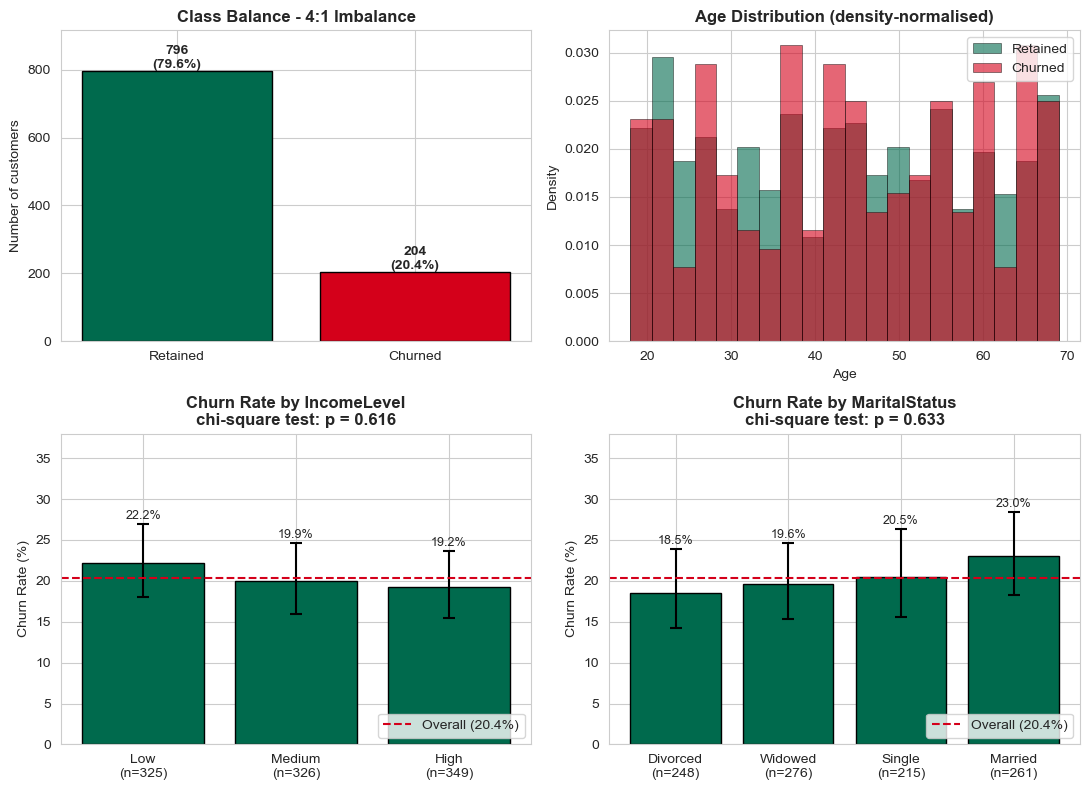

In [9]:
# Figure 1: class balance and demographic breakdowns
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

churn_counts = df['ChurnStatus'].value_counts().sort_index()
total = churn_counts.sum()
bars = axes[0, 0].bar(['Retained', 'Churned'], churn_counts.values,
                      color=[LLOYDS_GREEN, ACCENT_RED], edgecolor='black')
for bar, v in zip(bars, churn_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 10,
                    f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Number of customers')
axes[0, 0].set_title('Class Balance - 4:1 Imbalance', fontweight='bold')
axes[0, 0].set_ylim(0, max(churn_counts.values) * 1.15)

for status, colour, label in [(0, LLOYDS_GREEN, 'Retained'), (1, ACCENT_RED, 'Churned')]:
    axes[0, 1].hist(df[df['ChurnStatus']==status]['Age'], bins=20, density=True,
                    color=colour, alpha=0.6, label=label, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('Age'); axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Age Distribution (density-normalised)', fontweight='bold')
axes[0, 1].legend()

category_bar(axes[1, 0], 'IncomeLevel', df, order=['Low', 'Medium', 'High'])
category_bar(axes[1, 1], 'MaritalStatus', df)

plt.tight_layout()
plt.savefig('fig1_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

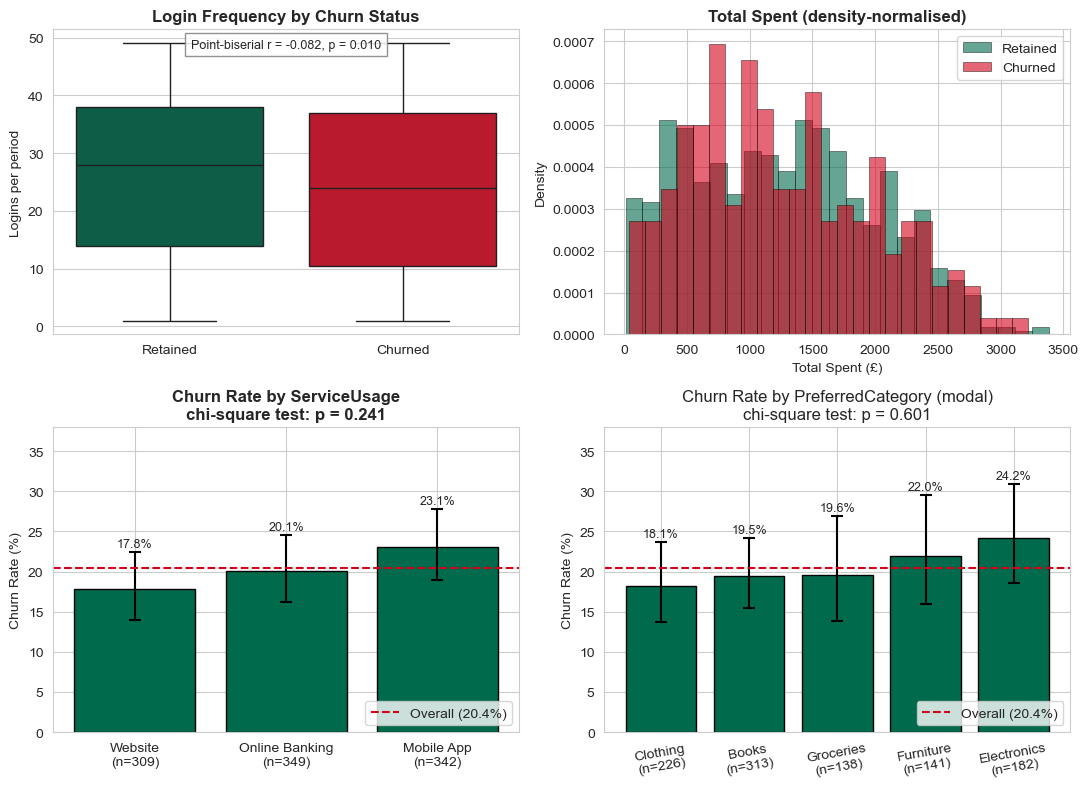

In [10]:
# Figure 2: behavioural patterns
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

df_box = df.assign(Status=df['ChurnStatus'].map({0: 'Retained', 1: 'Churned'}))
sns.boxplot(data=df_box, x='Status', y='LoginFrequency', hue='Status',
            palette=[LLOYDS_GREEN, ACCENT_RED], ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Login Frequency by Churn Status', fontweight='bold')
axes[0, 0].set_xlabel(''); axes[0, 0].set_ylabel('Logins per period')
r_lf, p_lf = stats.pointbiserialr(df['ChurnStatus'], df['LoginFrequency'])
axes[0, 0].text(0.5, 0.97, f'Point-biserial r = {r_lf:+.3f}, p = {p_lf:.3f}',
                transform=axes[0, 0].transAxes, ha='center', va='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey'))

for status, colour, label in [(0, LLOYDS_GREEN, 'Retained'), (1, ACCENT_RED, 'Churned')]:
    axes[0, 1].hist(df[df['ChurnStatus']==status]['TotalSpent'], bins=25, density=True,
                    color=colour, alpha=0.6, label=label, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('Total Spent (£)'); axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Total Spent (density-normalised)', fontweight='bold')
axes[0, 1].legend()

category_bar(axes[1, 0], 'ServiceUsage', df)
category_bar(axes[1, 1], '_modal_cat', df)
axes[1, 1].set_title(axes[1, 1].get_title().replace('_modal_cat', 'PreferredCategory (modal)'))
axes[1, 1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('fig2_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

### Spend-share analysis

Since the final feature set uses spend shares rather than the modal category, I am also looking at how spend shares differ between retained and churned customers. Mann-Whitney U is the appropriate test for the bounded, non-normal share distributions.

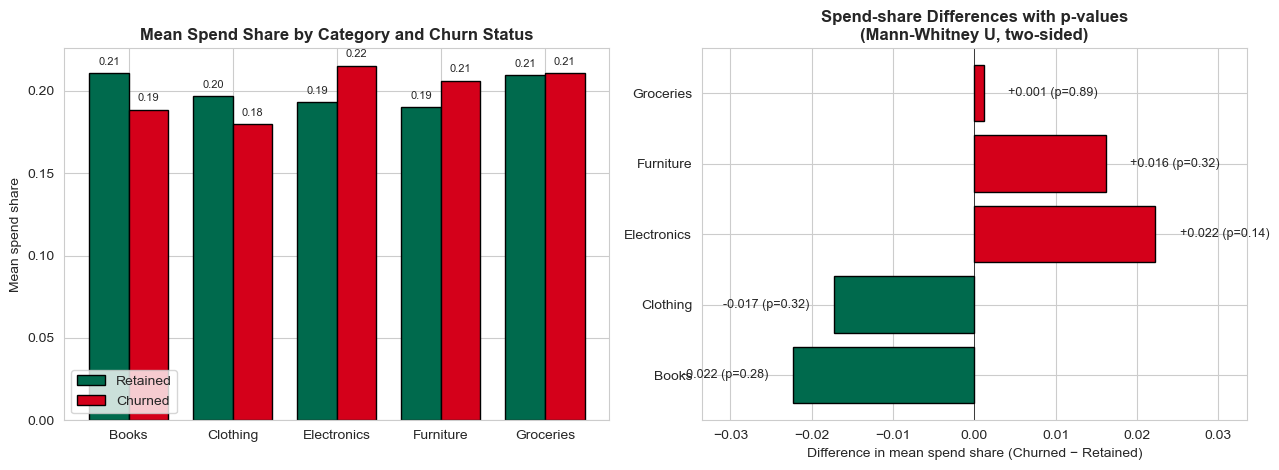

In [11]:
# Figure 3: SpendShare differences by churn status
categories = ['Books', 'Clothing', 'Electronics', 'Furniture', 'Groceries']
share_with_target = share.merge(df[['CustomerID', 'ChurnStatus']], on='CustomerID')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

retained_means = [share_with_target[share_with_target['ChurnStatus']==0][f'SpendShare_{c}'].mean() for c in categories]
churned_means = [share_with_target[share_with_target['ChurnStatus']==1][f'SpendShare_{c}'].mean() for c in categories]
x = np.arange(len(categories))
width = 0.38
axes[0].bar(x - width/2, retained_means, width, label='Retained',
            color=LLOYDS_GREEN, edgecolor='black')
axes[0].bar(x + width/2, churned_means, width, label='Churned',
            color=ACCENT_RED, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Mean spend share')
axes[0].set_title('Mean Spend Share by Category and Churn Status', fontweight='bold')
axes[0].legend()
for i, (r_, c_) in enumerate(zip(retained_means, churned_means)):
    axes[0].text(i - width/2, r_ + 0.005, f'{r_:.2f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, c_ + 0.005, f'{c_:.2f}', ha='center', fontsize=8)

diffs, pvals = [], []
for c in categories:
    col = f'SpendShare_{c}'
    diff = share_with_target[share_with_target['ChurnStatus']==1][col].mean() - share_with_target[share_with_target['ChurnStatus']==0][col].mean()
    diffs.append(diff)
    _, p_mw = stats.mannwhitneyu(share_with_target[share_with_target['ChurnStatus']==1][col],
                                  share_with_target[share_with_target['ChurnStatus']==0][col],
                                  alternative='two-sided')
    pvals.append(p_mw)

colours = [ACCENT_RED if d > 0 else LLOYDS_GREEN for d in diffs]
axes[1].barh(categories, diffs, color=colours, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Difference in mean spend share (Churned − Retained)')
axes[1].set_title('Spend-share Differences with p-values\n(Mann-Whitney U, two-sided)', fontweight='bold')
for i, (d, p_) in enumerate(zip(diffs, pvals)):
    axes[1].text(d + (0.003 if d >= 0 else -0.003), i,
                 f'{d:+.3f} (p={p_:.2f})',
                 va='center', ha='left' if d >= 0 else 'right', fontsize=9)
xmax = max(abs(min(diffs)), abs(max(diffs))) * 1.5
axes[1].set_xlim(-xmax, xmax)

plt.tight_layout()
plt.savefig('fig3_spendshare.png', dpi=150, bbox_inches='tight')
plt.show()

Spend-share differences between churned and retained customers are very small — under three percentage points across every category, and no Mann-Whitney p-value is below 0.14. The customer-level spend mix is essentially the same in both groups. This is consistent with the categorical and numerical analyses: no single feature in the supplied dataset carries strong individual signal.

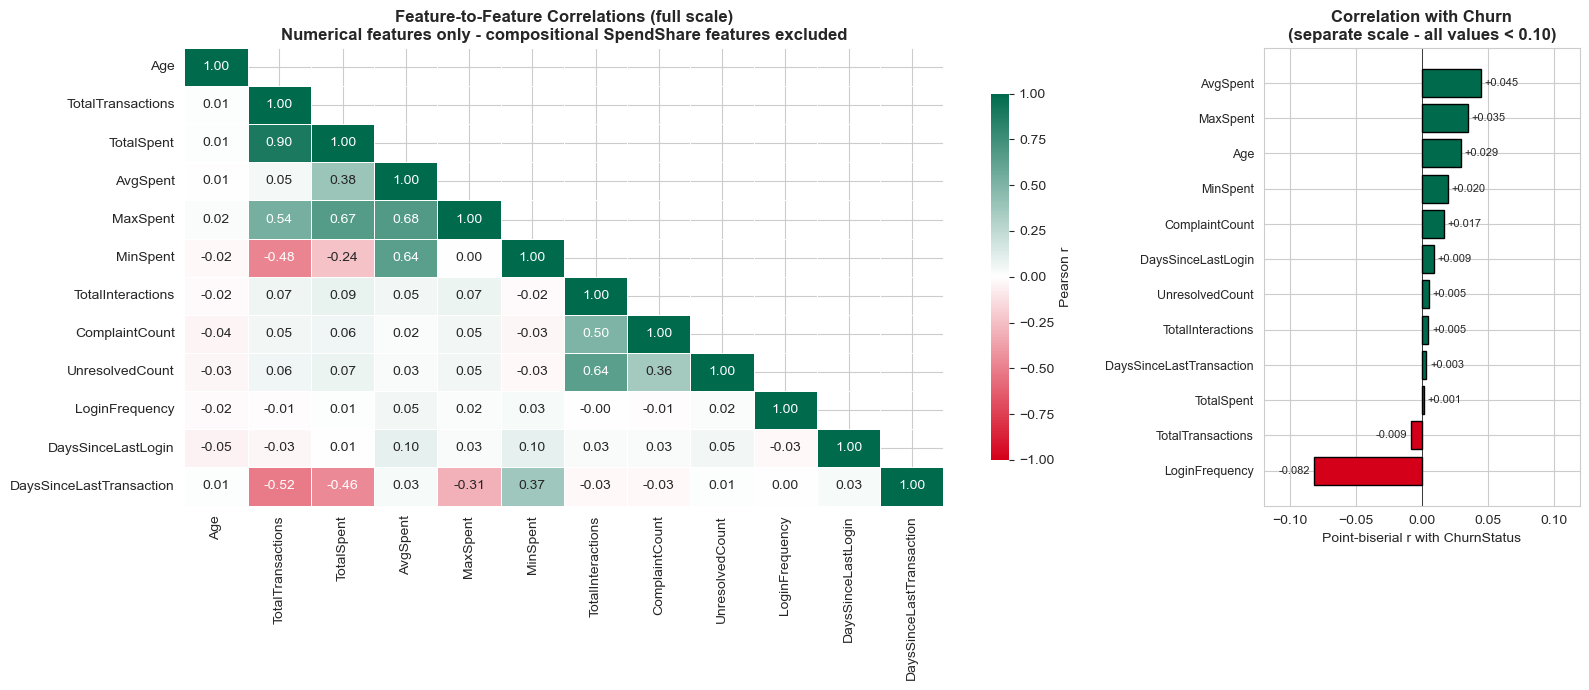

In [12]:
# Figure 4: correlation matrix and target correlations on separate scales
corr_full = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})

mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap=LLOYDS_DIV, center=0,
            vmin=-1, vmax=1, ax=axes[0], mask=mask,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
            linewidths=0.5, linecolor='white')
axes[0].set_title('Feature-to-Feature Correlations (full scale)\nNumerical features only - compositional SpendShare features excluded',
                  fontweight='bold')

target_corrs = df[num_cols + ['ChurnStatus']].corr()['ChurnStatus'].drop('ChurnStatus').sort_values()
colours = [ACCENT_RED if r < 0 else LLOYDS_GREEN for r in target_corrs.values]
axes[1].barh(range(len(target_corrs)), target_corrs.values, color=colours, edgecolor='black')
axes[1].set_yticks(range(len(target_corrs)))
axes[1].set_yticklabels(target_corrs.index, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlim(-0.12, 0.12)
axes[1].set_xlabel('Point-biserial r with ChurnStatus')
axes[1].set_title('Correlation with Churn\n(separate scale - all values < 0.10)', fontweight='bold')
for i, r in enumerate(target_corrs.values):
    axes[1].text(r + (0.003 if r >= 0 else -0.003), i, f'{r:+.3f}',
                 ha='left' if r >= 0 else 'right', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

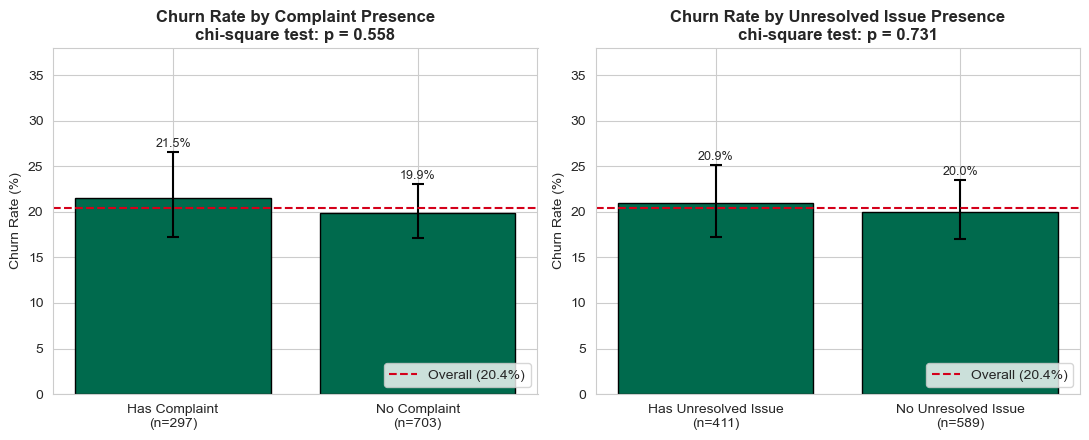

In [13]:
# Figure 5: service-friction patterns
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, base_var, friction_label in [
    (axes[0], 'ComplaintCount', 'Complaint'),
    (axes[1], 'UnresolvedCount', 'Unresolved Issue')
]:
    helper = (df[base_var] > 0).map({True: f'Has {friction_label}', False: f'No {friction_label}'})
    helper_df = pd.DataFrame({'group': helper, 'churn': df['ChurnStatus']})
    grp = helper_df.groupby('group')['churn'].agg(['sum', 'count'])
    rates, lows, highs, labels = [], [], [], []
    for level, row in grp.iterrows():
        p, lo, hi = wilson_ci(int(row['sum']), int(row['count']))
        rates.append(p*100); lows.append(p*100-lo*100); highs.append(hi*100-p*100)
        labels.append(f'{level}\n(n={int(row["count"])})')
    ax.bar(labels, rates, color=LLOYDS_GREEN, edgecolor='black')
    ax.errorbar(range(len(rates)), rates, yerr=[lows, highs], fmt='none',
                ecolor='black', capsize=4, capthick=1.5, linewidth=1.5)
    ax.set_ylabel('Churn Rate (%)')
    ax.axhline(20.4, color=ACCENT_RED, linestyle='--', linewidth=1.5, label='Overall (20.4%)')
    for i, (r, h) in enumerate(zip(rates, highs)):
        ax.text(i, r + h + 0.6, f'{r:.1f}%', ha='center', fontsize=9)
    ax.legend(loc='lower right'); ax.set_ylim(0, 38)
    ct = pd.crosstab(helper, df['ChurnStatus'])
    _, p_chi, _, _ = stats.chi2_contingency(ct, correction=False)
    ax.set_title(f'Churn Rate by {friction_label} Presence\nchi-square test: p = {p_chi:.3f}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_service.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cleaning and encoding the final dataset

I am now producing the model-ready dataset. The encoding decisions follow the type of each variable: ordinal for income, binary for gender, one-hot for marital status and channel. The spend-share features stay as numeric proportions. The original date columns are dropped — their information lives in the recency features. I am leaving the EDA-only modal-category column out of the final dataset, since the spend shares carry the same information in a richer form.

In [14]:
df_clean = df.drop(columns=['LastTransactionDate', 'LastLoginDate', '_modal_cat']).copy()
df_clean['IncomeLevel_Ord'] = df_clean['IncomeLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_clean['Gender_M'] = (df_clean['Gender'] == 'M').astype(int)
df_clean = pd.get_dummies(df_clean, columns=['MaritalStatus', 'ServiceUsage'],
                          prefix=['Marital', 'Channel'], drop_first=False)
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)
df_clean = df_clean.drop(columns=['Gender', 'IncomeLevel'])

ordered_cols = ['CustomerID', 'ChurnStatus', 'Age', 'Gender_M', 'IncomeLevel_Ord',
                'Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Widowed',
                'TotalTransactions', 'TotalSpent', 'AvgSpent', 'MaxSpent', 'MinSpent',
                'SpendShare_Books', 'SpendShare_Clothing', 'SpendShare_Electronics',
                'SpendShare_Furniture', 'SpendShare_Groceries',
                'TotalInteractions', 'ComplaintCount', 'UnresolvedCount',
                'LoginFrequency', 'DaysSinceLastLogin', 'DaysSinceLastTransaction',
                'Channel_Mobile App', 'Channel_Online Banking', 'Channel_Website']
df_clean = df_clean[ordered_cols]

print(f'Final dataset: {df_clean.shape}')
print(f'  1 CustomerID + 1 ChurnStatus target + {df_clean.shape[1] - 2} predictor features')
df_clean.head(3)

Final dataset: (1000, 28)
  1 CustomerID + 1 ChurnStatus target + 26 predictor features


,CustomerID,ChurnStatus,Age,Gender_M,IncomeLevel_Ord,Marital_Divorced,Marital_Married,Marital_Single,Marital_Widowed,TotalTransactions,TotalSpent,AvgSpent,MaxSpent,MinSpent,SpendShare_Books,SpendShare_Clothing,SpendShare_Electronics,SpendShare_Furniture,SpendShare_Groceries,TotalInteractions,ComplaintCount,UnresolvedCount,LoginFrequency,DaysSinceLastLogin,DaysSinceLastTransaction,Channel_Mobile App,Channel_Online Banking,Channel_Website
0,1,0,62,1,0,0,0,1,0,1,416.500,416.500,416.500,416.500,0.000,0.000,1.000,0.000,0.000,1,0,0,34,72,645,1,0,0
1,2,1,65,1,0,0,1,0,0,7,"1,547.420",221.060,397.370,54.960,0.000,0.292,0.513,0.065,0.129,1,0,0,5,27,408,0,0,1
2,3,0,18,1,0,0,0,1,0,6,"1,702.980",283.830,419.950,51.070,0.142,0.030,0.000,0.483,0.345,1,0,0,3,47,450,0,0,1


## 9. Scaling is intentionally deferred to Phase 2

I have not fitted a scaler on this dataset. Fitting `StandardScaler` on all 1,000 rows before splitting into train and test sets is a form of data leakage: the test fold's distribution would be used to compute the mean and standard deviation applied to the training fold. The deliverable is therefore unscaled. The cell below shows the correct pattern for Phase 2 — the scaler sits inside a scikit-learn `Pipeline` and only ever sees the training fold of each cross-validation split. I have used a regularised logistic regression to make the pattern concrete; this also serves as a defensible baseline that Phase 2 can improve on.

In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X = df_clean.drop(columns=['CustomerID', 'ChurnStatus'])
y = df_clean['ChurnStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', penalty='l2', max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipe, X_train, y_train, cv=cv,
    scoring={'roc_auc': 'roc_auc',
             'pr_auc': 'average_precision',
             'f1': 'f1',
             'recall': 'recall',
             'precision': 'precision'}
)

print('Regularised logistic-regression baseline — 5-fold CV on the training set:')
for metric in ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision']:
    arr = scores[f'test_{metric}']
    print(f'  {metric:10s}  {arr.mean():.3f} ± {arr.std():.3f}')

Regularised logistic-regression baseline — 5-fold CV on the training set:
  roc_auc     0.514 ± 0.040
  pr_auc      0.241 ± 0.026
  f1          0.306 ± 0.038
  recall      0.498 ± 0.075
  precision   0.221 ± 0.026


The baseline ROC-AUC sits around 0.51 with a wide confidence band — barely better than chance. PR-AUC is close to the 20.4% positive-class prevalence, which is the no-information floor for that metric. This is a useful sanity result: it tells me that the supplied features, in their current form, do not contain a strong predictive signal for churn. Phase 2 should expect tree-based models to do somewhat better through interactions, but the realistic ceiling on this dataset is modest. Anything above 0.80 ROC-AUC should be inspected closely for leakage rather than treated as a success.

## 10. Deliverable workbook

The cleaned dataset, the data dictionary and the modelling notes for Phase 2 are written to a single workbook. The data dictionary calls out the multicollinearity and temporal-leakage flags so they cannot be overlooked. The modelling-notes sheet states the pipeline pattern, the evaluation metrics and the fairness checks that Phase 2 needs to run.

In [16]:
data_dict = pd.DataFrame([
    ('CustomerID', 'Identifier', '—', 'Drop before modelling.'),
    ('ChurnStatus', 'Target', '0/1', '1 if churned. Class balance 79.6 to 20.4.'),
    ('Age', 'Demographic', '18–69', 'Customer age.'),
    ('Gender_M', 'Demographic (binary)', '0/1', 'Protected characteristic — see Responsible Use section of the report.'),
    ('IncomeLevel_Ord', 'Demographic (ordinal)', '0/1/2', 'Sensitive variable. Low=0, Medium=1, High=2.'),
    ('Marital_*', 'Demographic (one-hot)', '0/1', 'Four dummies. Drop one for non-regularised linear models.'),
    ('TotalTransactions', 'Transaction', '1–9', 'VIF=16.9 — severe multicollinearity with TotalSpent and AvgSpent.'),
    ('TotalSpent', 'Transaction (£)', '9.80–3,386', 'VIF=18.4.'),
    ('AvgSpent', 'Transaction (£)', '9.80–497', 'VIF=17.0.'),
    ('MaxSpent', 'Transaction (£)', '9.80–500', 'VIF=6.8 — moderate.'),
    ('MinSpent', 'Transaction (£)', '5.18–497', 'VIF=5.9 — moderate.'),
    ('SpendShare_*', 'Transaction (compositional)', '0–1', 'Five shares sum to 1.0 per customer. Drop one for non-regularised linear models.'),
    ('TotalInteractions', 'Service', '0–2', '0 = no service contact in the observation period.'),
    ('ComplaintCount', 'Service', '0–2', 'Count of complaint-type interactions.'),
    ('UnresolvedCount', 'Service', '0–2', 'Count of interactions marked unresolved.'),
    ('LoginFrequency', 'Online', '1–49', 'Strongest individual numerical feature (r=-0.082, p=0.010). TEMPORAL-LEAKAGE RISK — see report 4.1.'),
    ('DaysSinceLastLogin', 'Online', '1–365', 'TEMPORAL-LEAKAGE RISK — verify churn-measurement date before using.'),
    ('DaysSinceLastTransaction', 'Transaction', '366–731', 'Reference date 1 Jan 2024 is provisional.'),
    ('Channel_*', 'Online (one-hot)', '0/1', 'Three channels: Mobile App, Online Banking, Website. Drop one for non-regularised linear models.'),
], columns=['Feature', 'Type', 'Range', 'Notes'])

modelling_notes = pd.DataFrame([
    ('1', 'Class imbalance', 'class_weight=balanced or SMOTE inside CV folds. Never resample before splitting.'),
    ('2', 'Train/test split', 'Proportional sampling on ChurnStatus to preserve the 79.6/20.4 split in both folds.'),
    ('3', 'Scaling', 'Fit StandardScaler inside a Pipeline on the training fold only.'),
    ('4', 'Multicollinearity', 'TotalTransactions, TotalSpent, AvgSpent have VIF > 15. Drop two or use L1/L2 regularisation.'),
    ('5', 'Compositional features', 'The five SpendShare columns sum to 1.0 per customer. Drop one for non-regularised linear models.'),
    ('6', 'Dummy variables', 'Drop one column per Marital_*, Channel_* block for non-regularised linear models.'),
    ('7', 'Temporal leakage', 'Verify ChurnStatus measurement date. Re-check LoginFrequency and DaysSinceLastLogin if leakage is possible.'),
    ('8', 'Primary metrics', 'PR-AUC, precision, recall, F1 for the positive class. ROC-AUC as secondary. Accuracy is not informative.'),
    ('9', 'Recall at top-k', 'Report recall@10% if the retention team contacts only the top 10% riskiest customers.'),
    ('10', 'Calibration', 'Reliability diagram and Brier score. Retention spend depends on probabilities, not rankings.'),
    ('11', 'Sample size', '204 churners. Wide confidence intervals on every metric. Simpler models first.'),
    ('12', 'Feature importance', 'SHAP values rather than raw importances, given the multicollinearity in transaction features.'),
    ('13', 'Fairness', 'Performance across Gender_M, IncomeLevel_Ord, Marital_*. See Responsible Use section in the report.'),
], columns=['#', 'Topic', 'Guidance for Phase 2'])

with pd.ExcelWriter('Cleaned_Customer_Churn_Data.xlsx', engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    data_dict.to_excel(writer, sheet_name='Data_Dictionary', index=False)
    modelling_notes.to_excel(writer, sheet_name='Modelling_Notes', index=False)

print('Saved Cleaned_Customer_Churn_Data.xlsx')
print(f'  Cleaned_Data:    {df_clean.shape}')
print(f'  Data_Dictionary: {data_dict.shape}')
print(f'  Modelling_Notes: {modelling_notes.shape}')

Saved Cleaned_Customer_Churn_Data.xlsx
  Cleaned_Data:    (1000, 28)
  Data_Dictionary: (19, 4)
  Modelling_Notes: (13, 3)


## Summary

I have produced a clean, customer-level dataset of 1,000 rows and 26 predictor features that is ready for Phase 2 modelling. The exploratory analysis surfaces three points worth raising in our review meeting:

1. **No single feature in the current set is a strong predictor of churn.** `LoginFrequency` is the only individually significant numerical feature at p < 0.05, and its correlation is only -0.082. Every categorical variable produces chi-square p-values above 0.24. A regularised logistic-regression baseline scores ROC-AUC 0.51 — barely better than chance.

2. **Three structural risks affect Phase 2.** The first is temporal: the transaction window is 2022, the online-activity window is 2023, and the churn-measurement date is undefined. We need to verify this with the project sponsor before Phase 2 starts. The second is data availability: the brief asks about working professionals and small-business owners, but the data has no occupation, employment-status or SME-account fields. The third is sample size: with only 204 positives, every model metric will have a wide confidence interval.

3. **The cleaning work is done, and Phase 2 has a clear runway.** The workbook includes a data dictionary that flags multicollinearity and leakage risks, and a modelling-notes sheet with 13 specific guidelines covering imbalance, scaling, evaluation metrics, calibration and fairness.

I would like to discuss the three risks above before kicking off Phase 2 modelling work.